In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import pearsonr
from scipy import stats
import joblib
import warnings 

In [2]:
df = pd.read_csv("../../../data/combined/multi_class_pothole/combined.csv")

In [3]:
# Get unique window IDs and split those instead of rows
unique_windows = df['window_id'].unique()
train_ids, test_ids = train_test_split(unique_windows, test_size=0.2, random_state=42)

# Create train and test dataframes based on those IDs
train = df[df['window_id'].isin(train_ids)]
test = df[df['window_id'].isin(test_ids)]



In [4]:
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

Train columns: ['window_id', 'step', 'ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed', 'label']
Test columns: ['window_id', 'step', 'ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed', 'label']


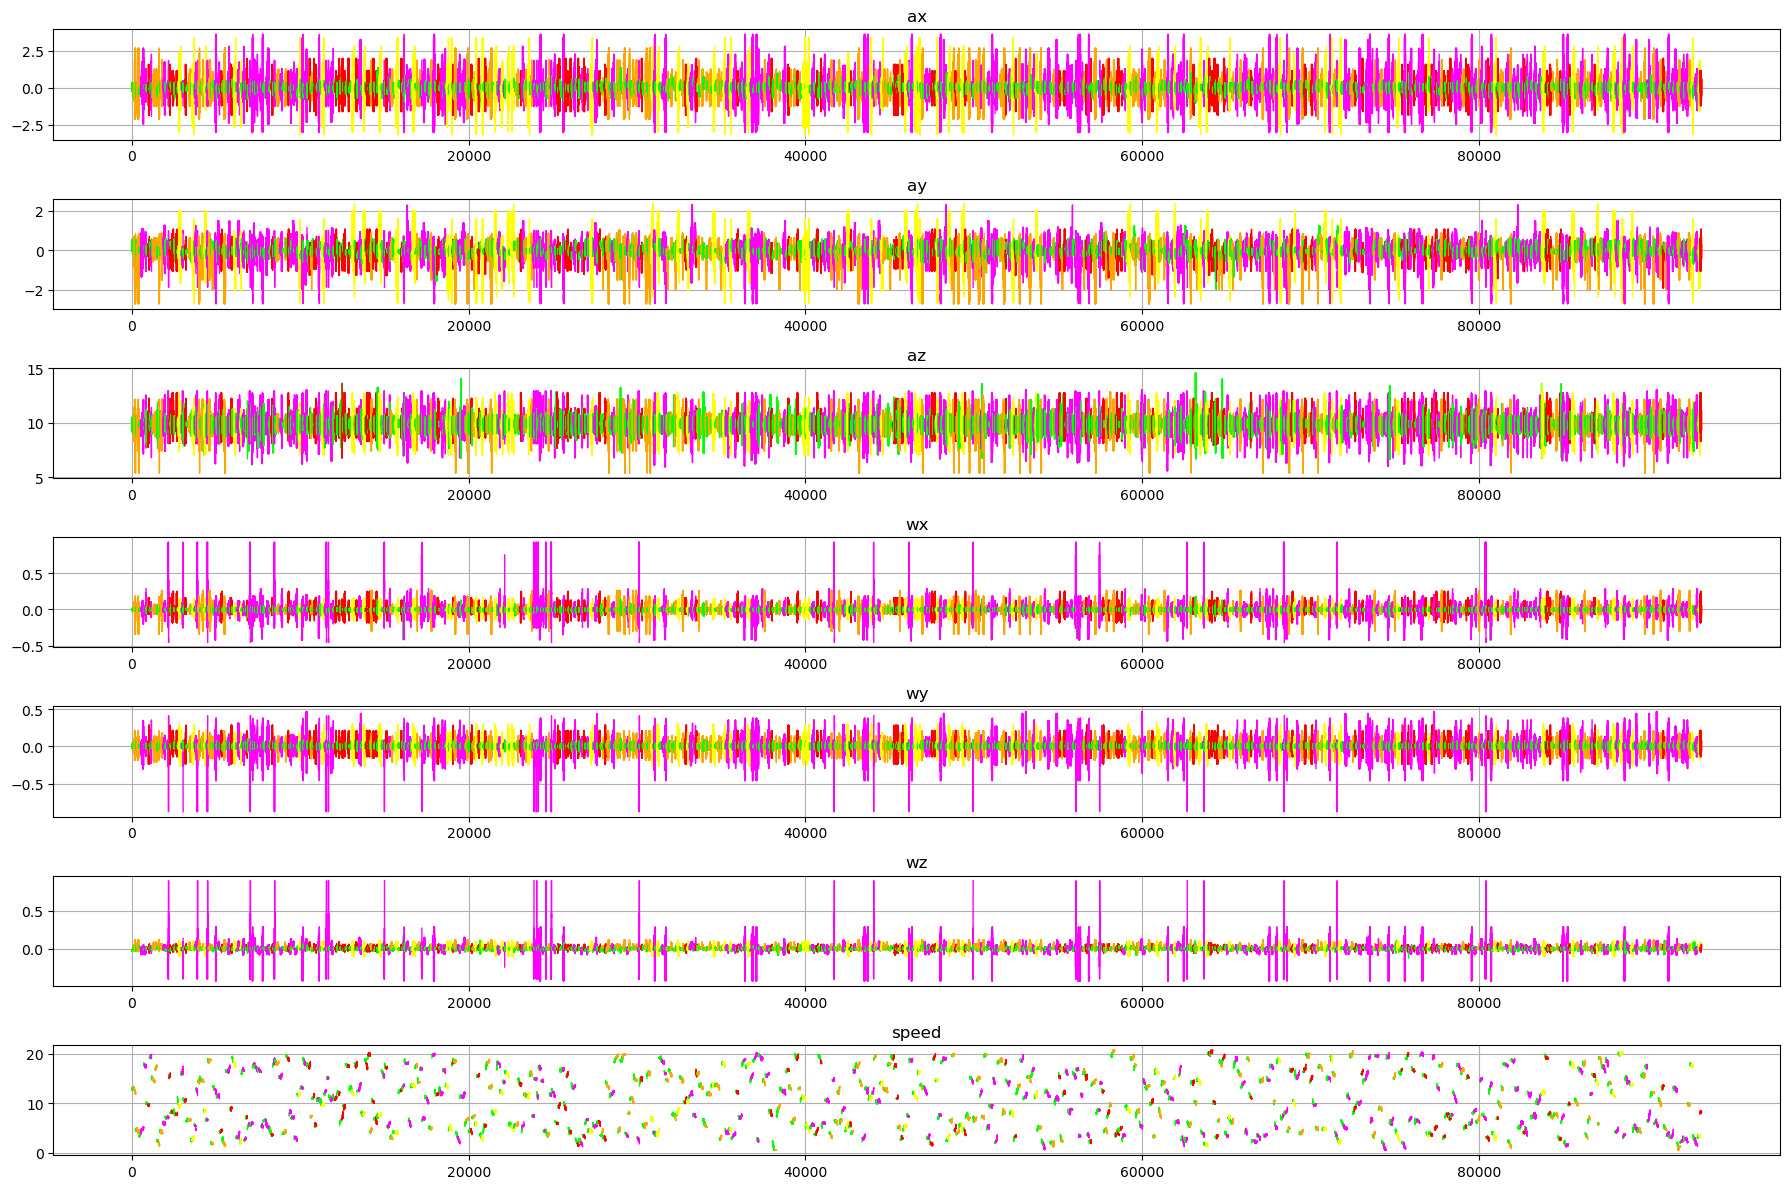

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Color mapping =====
label_colors = {
    0: "#00FF00",   # green
    1: "#FFFF00",   # yellow
    2: "#FFA500",   # orange
    3: "#FF0000",   # red
    4: "#FF00FF"    # magenta
}

features = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
x_full = np.arange(len(train))

plt.figure(figsize=(18, 12))

for idx, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, idx)

    start = 0
    while start < len(train):
        current_label = train['label'].iloc[start]
        end = start

        # find continuous segment with same label
        while end < len(train) and train['label'].iloc[end] == current_label:
            end += 1

        plt.plot(
            x_full[start:end],
            train[feature].iloc[start:end],
            color=label_colors[current_label],
            linewidth=1
        )

        start = end

    plt.title(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()


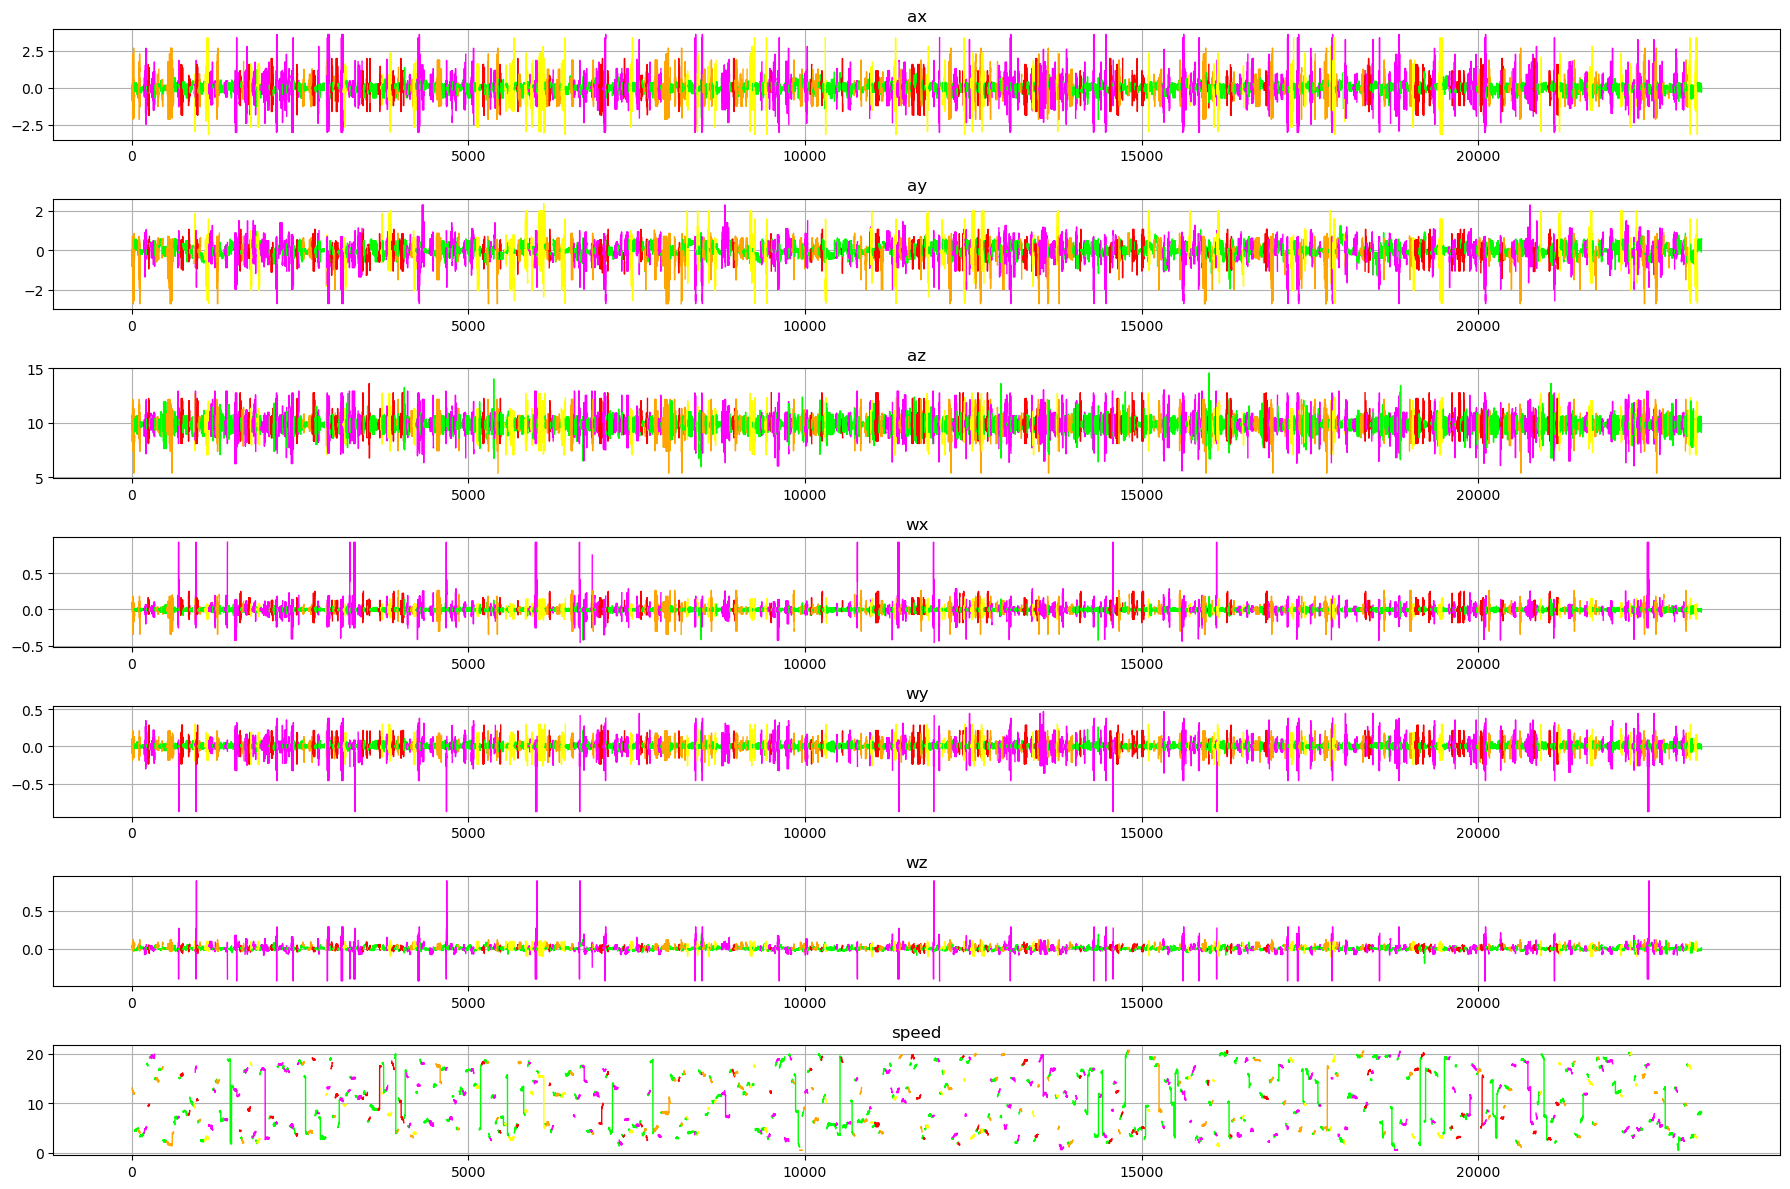

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Color mapping =====
label_colors = {
    0: "#00FF00",   # green
    1: "#FFFF00",   # yellow
    2: "#FFA500",   # orange
    3: "#FF0000",   # red
    4: "#FF00FF"    # magenta
}

features = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
x_full = np.arange(len(test))

plt.figure(figsize=(18, 12))

for idx, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, idx)

    start = 0
    while start < len(test):
        current_label = test['label'].iloc[start]
        end = start

        # find continuous segment with same label
        while end < len(test) and test['label'].iloc[end] == current_label:
            end += 1

        plt.plot(
            x_full[start:end],
            test[feature].iloc[start:end],
            color=label_colors[current_label],
            linewidth=1
        )

        start = end

    plt.title(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()


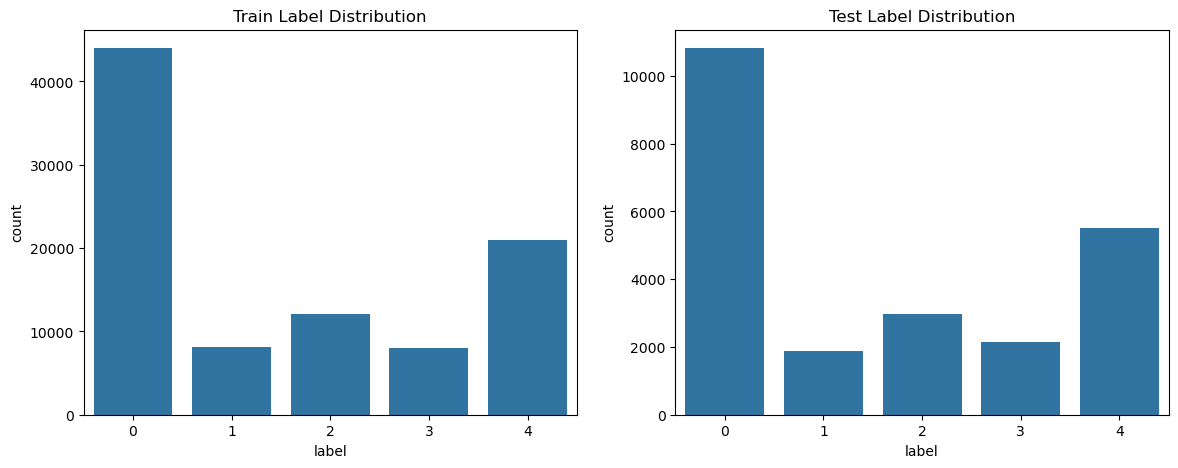

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='label', data=train, ax=axes[0])
axes[0].set_title('Train Label Distribution')

sns.countplot(x='label', data=test, ax=axes[1])
axes[1].set_title('Test Label Distribution')

plt.show()



### 1. Data Reshaping & Feature Extraction
We need to convert the long-form CSV structure into the dual-input format: 3D tensors for the CNN and 2D vectors for the MLP.

In [8]:
def extract_stat_features(series, stats_row):
    stats_row.append(np.mean(series))
    stats_row.append(np.std(series))
    stats_row.append(np.sqrt(np.mean(series**2)))  # RMS
    stats_row.append(np.max(series) - np.min(series))  # Range

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        stats_row.append(stats.skew(series, bias=False))
        stats_row.append(stats.kurtosis(series, fisher=True, bias=False))

def prepare_dual_input(df, scalers=None):
    feature_cols = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'speed']
    groups = [group for _, group in df.groupby('window_id')]

    # ===== CNN INPUT (unchanged) =====
    X_cnn_raw = np.array([g[feature_cols].values for g in groups])

    # ===== MLP INPUT (physics + stats features) =====
    X_mlp_raw = []

    for g in groups:
        stats_row = []

        wx, wy = g['wx'].values, g['wy'].values
        az, ay = g['az'].values, g['ay'].values

        # ---- Original physics features ----
        cov = pearsonr(wx, wy)[0] if (np.std(wx) > 1e-5 and np.std(wy) > 1e-5) else 0
        roll_ratio = np.std(wy) / (np.std(wx) + 1e-6)
        slope = np.mean(np.gradient(wx[:10]))

        stats_row.extend([
            cov,
            roll_ratio,
            slope,
            np.min(az),
            np.ptp(az),
            np.mean(ay),
            np.mean(g['speed'])
        ])

        # ---- NEW: statistical features per signal ----
        for col in feature_cols:
            series = g[col].values
            extract_stat_features(series, stats_row)

        X_mlp_raw.append(stats_row)

    X_mlp_raw = np.array(X_mlp_raw)
    X_mlp_raw = np.nan_to_num(X_mlp_raw)
    X_cnn_raw = np.nan_to_num(X_cnn_raw)
    y = np.array([g['label'].iloc[0] for g in groups])

    # ===== Scaling =====
    if scalers is None:
        sc_cnn = StandardScaler()
        sc_mlp = StandardScaler()

        N, T, F = X_cnn_raw.shape
        X_cnn = sc_cnn.fit_transform(X_cnn_raw.reshape(-1, F)).reshape(N, T, F)
        X_mlp = sc_mlp.fit_transform(X_mlp_raw)

        return X_cnn, X_mlp, y, (sc_cnn, sc_mlp)
    else:
        sc_cnn, sc_mlp = scalers

        N, T, F = X_cnn_raw.shape
        X_cnn = sc_cnn.transform(X_cnn_raw.reshape(-1, F)).reshape(N, T, F)
        X_mlp = sc_mlp.transform(X_mlp_raw)

        return X_cnn, X_mlp, y

# Execute Preparation
X_train_cnn, X_train_mlp, y_train, scalers = prepare_dual_input(train)

X_test_cnn, X_test_mlp, y_test = prepare_dual_input(test, scalers=scalers)

# ===== MANUAL OVERSAMPLING =====
from sklearn.utils import resample
print("Original Class Distribution:", np.bincount(y_train))

# Combine for resampling
train_indices = np.arange(len(y_train))
X_resampled_idx = []
y_resampled = []

class_counts = np.bincount(y_train)
max_samples = np.max(class_counts)

for label in range(len(class_counts)):
    indices = train_indices[y_train == label]
    if len(indices) == 0: continue
    
    # Upsample
    upsampled_indices = resample(indices, replace=True, n_samples=max_samples, random_state=42)
    X_resampled_idx.extend(upsampled_indices)
    y_resampled.extend([label] * max_samples)

X_resampled_idx = np.array(X_resampled_idx)
# Shuffle
shuffle_idx = np.random.permutation(len(X_resampled_idx))
X_resampled_idx = X_resampled_idx[shuffle_idx]
y_train = np.array(y_resampled)[shuffle_idx]

X_train_cnn = X_train_cnn[X_resampled_idx]
X_train_mlp = X_train_mlp[X_resampled_idx]

print("Resampled Class Distribution:", np.bincount(y_train))


# Save scalers for mobile pre-processing
joblib.dump(scalers[0], 'scaler_cnn.pkl')
joblib.dump(scalers[1], 'scaler_mlp.pkl')

Original Class Distribution: [2200  405  607  401 1048]
Resampled Class Distribution: [2200 2200 2200 2200 2200]


['scaler_mlp.pkl']

### 2. Model Architecture & Training
This implements the hybrid structure we discussed, joining the temporal pattern recognition of the CNN with the explicit physics logic of the MLP.

In [10]:
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers

class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.reshape(y_true, [-1]) # Ensure flat
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = self.alpha * y_true_oh * tf.math.pow((1 - y_pred), self.gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))


def build_hybrid_model():
    l2 = regularizers.l2(1e-4)

    # ===== CNN Branch: Temporal Learning =====
    cnn_in = layers.Input(shape=(20, 7), name="CNN_Input")

    x1 = layers.Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=l2)(cnn_in)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.SpatialDropout1D(0.2)(x1)

    x1 = layers.Conv1D(128, 3, padding='same', activation='relu', kernel_regularizer=l2)(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.SpatialDropout1D(0.2)(x1)

    x1 = layers.GlobalMaxPooling1D()(x1)

    # ===== MLP Branch: Logical Features =====
    mlp_in = layers.Input(shape=(49,), name="MLP_Input")

    x2 = layers.Dense(64, activation='relu', kernel_regularizer=l2)(mlp_in)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)

    x2 = layers.Dense(32, activation='relu', kernel_regularizer=l2)(x2)
    x2 = layers.Dropout(0.3)(x2)

    # ===== Fusion =====
    combined = layers.Concatenate()([x1, x2])

    z = layers.Dense(128, activation='relu', kernel_regularizer=l2)(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(64, activation='relu', kernel_regularizer=l2)(z)
    z = layers.Dropout(0.4)(z)

    output = layers.Dense(5, activation='softmax')(z)

    model = models.Model(inputs=[cnn_in, mlp_in], outputs=output)

    opt = optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=opt,
        loss=SparseFocalLoss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    return model
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_hybrid_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
model = build_hybrid_model()

history = model.fit(
    x=[X_train_cnn, X_train_mlp],
    y=y_train,
    validation_data=([X_test_cnn, X_test_mlp], y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/10
342/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5408 - loss: 0.2751
Epoch 1: val_loss improved from None to 0.07075, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6775 - loss: 0.1791 - val_accuracy: 0.9271 - val_loss: 0.0707 - learning_rate: 0.0010
Epoch 2/10
339/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8719 - loss: 0.0876
Epoch 2: val_loss improved from 0.07075 to 0.05316, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8870 - loss: 0.0809 - val_accuracy: 0.9648 - val_loss: 0.0532 - learning_rate: 0.0010
Epoch 3/10
338/344 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9282 - loss: 0.0650
Epoch 3: val_loss improved from 0.05316 to 0.04808, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9332 - loss: 0.0619 - val_accuracy: 0.9751 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 4/10
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9552 - loss: 0.0532
Epoch 4: val_loss improved from 0.04808 to 0.04431, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9564 - loss: 0.0523 - val_accuracy: 0.9777 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 5/10
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9690 - loss: 0.0473
Epoch 5: val_loss improved from 0.04431 to 0.04107, saving model to best_hybrid_model.h5


...

344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9714 - loss: 0.0420 - val_accuracy: 0.9820 - val_loss: 0.0376 - learning_rate: 0.0010
Epoch 7/10
339/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9748 - loss: 0.0407
Epoch 7: val_loss improved from 0.03761 to 0.03619, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9769 - loss: 0.0390 - val_accuracy: 0.9897 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 8/10
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9811 - loss: 0.0357
Epoch 8: val_loss improved from 0.03619 to 0.03250, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9823 - loss: 0.0345 - val_accuracy: 0.9880 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 9/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9769 - loss: 0.0337
Epoch 9: val_loss improved from 0.03250 to 0.03086, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9790 - loss: 0.0332 - val_accuracy: 0.9863 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 10/10
340/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9821 - loss: 0.0304
Epoch 10: val_loss improved from 0.03086 to 0.02884, saving model to best_hybrid_model.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9835 - loss: 0.0294 - val_accuracy: 0.9846 - val_loss: 0.0288 - learning_rate: 0.0010


### 3. Deployment Conversion (.h5 & .tflite)
To run this on the edge, we save the Keras model and convert it to a quantized TensorFlow Lite format.

In [11]:
# Save Keras Model
model.save("pothole_severity_model.h5")

# Convert to TFLite for mobile use
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Quantization for speed
tflite_model = converter.convert()

with open("pothole_model.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpq5hji2qg\assets


INFO:tensorflow:Assets written to: C:\Users\nishk\AppData\Local\Temp\tmpq5hji2qg\assets


Saved artifact at 'C:\Users\nishk\AppData\Local\Temp\tmpq5hji2qg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 20, 7), dtype=tf.float32, name='CNN_Input'), TensorSpec(shape=(None, 49), dtype=tf.float32, name='MLP_Input')]
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2707802475152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707916292864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707759722240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707759715376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707759713968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707759719424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707759726112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707916511488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707916511312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2707916514

### 4. Performance Evaluation
We visualize the Confusion Matrix to ensure the model distinguishes between vibrations (1) and medium potholes (3) effectively.

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


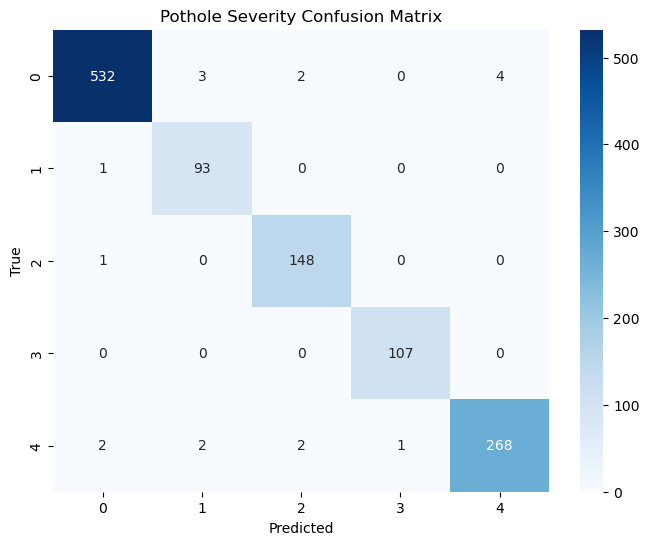

In [12]:
y_pred = np.argmax(model.predict([X_test_cnn, X_test_mlp]), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.title('Pothole Severity Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()